## Circuit layout

Here we provide an example of PIC layout with the ltoi300 PDK. We start by
choosing a die floorplan compatible with a submission for an LXT MPW run,
then place some edge couplers for I/O at the right locations on the chip
frame. We create a circuit cell with an evanescently-coupled ring
resonator and connect it with the input and output edge couplers.
We also create routed modulator cells.

In [ ]:
from functools import partial
from pathlib import Path

import gdsfactory as gf
import numpy as np
from gdsfactory.routing import route_bundle

import ltoi300  # noqa: F401  – activates the PDK
from _utils.chip_floorplan import chip_frame
from ltoi300.tech import LAYER

2026-03-05 14:44:16.153 | INFO     | kfactory.kcell:show:4029 - klive v0.3.3: Reloaded file 'C:\Users\ANDREI~1\AppData\Local\Temp\296017590_die_assembled_0168a00c.oas'


### Choose the chip format and display the outline

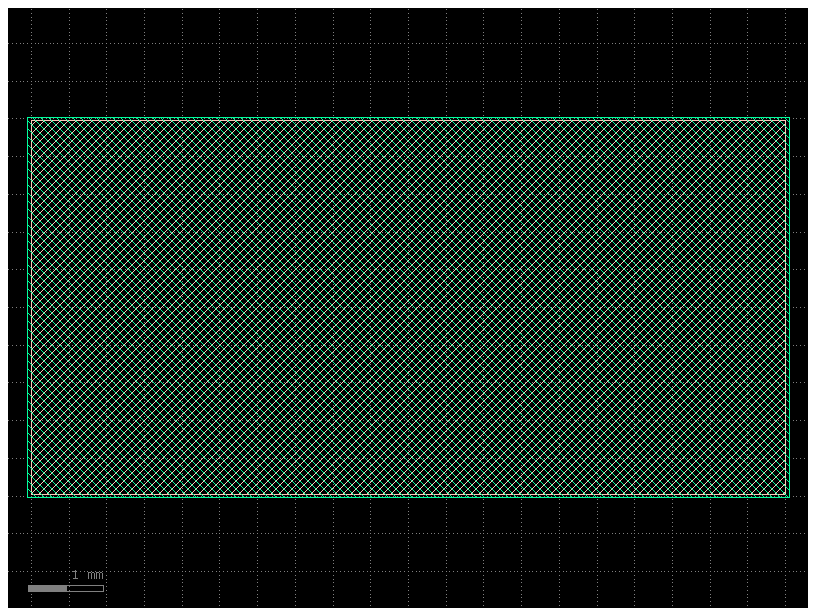

In [2]:
chip_layout = chip_frame()
chip_layout

### Get the O-band ring resonator and edge couplers

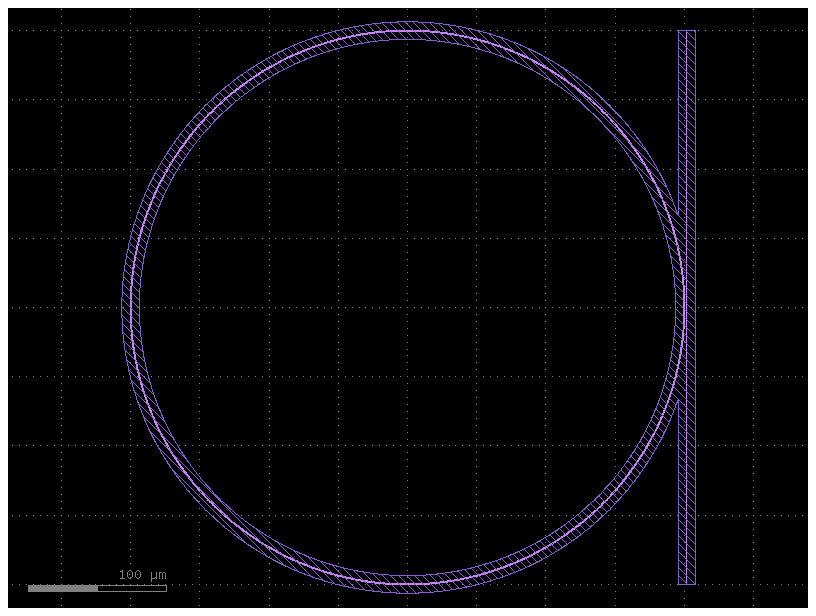

In [3]:
ring_resonator_oband = gf.get_component("ring_resonator_single_mode_point_coupler_oband")
ring_resonator_oband

In [4]:
x_in = chip_layout.dxmin + 100.0
in_loc = np.array([x_in, chip_layout.dymax])
out_loc = np.array(
    [x_in + 2.5 * ring_resonator_oband.settings["ring_radius"], chip_layout.dymin]
)

ec_in = gf.Component()
ec_oband = gf.get_component("edge_coupler_oband")
ec_ref = ec_in << ec_oband
ec_ref.drotate(-90.0)
ec_ref.dmove(
    ec_ref.ports["o1"].dcenter, in_loc + [0.0, 0.5 * ec_oband.settings["input_ext"]]
)
ec_in.add_ports(ec_ref.ports)

ec_out = gf.Component()
ec_ref = ec_out << ec_oband
ec_ref.drotate(90.0)
ec_ref.dmove(
    ec_ref.ports["o1"].dcenter, out_loc - [0.0, 0.5 * ec_oband.settings["input_ext"]]
)
ec_out.add_ports(ec_ref.ports)

ecs_oband = {
    "in": ec_in,
    "out": ec_out,
}

### Get the C-band ring resonator and edge couplers

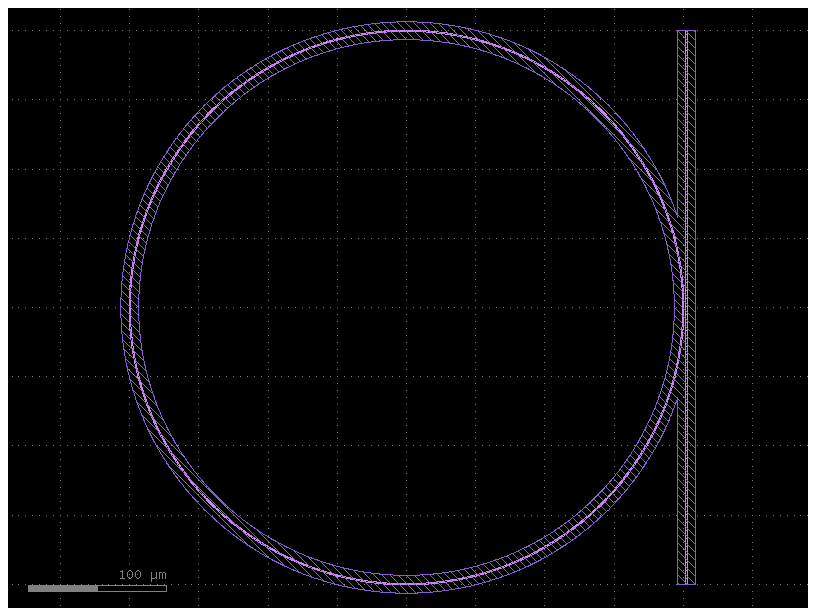

In [5]:
ring_resonator_cband = gf.get_component("ring_resonator_single_mode_point_coupler_cband")
ring_resonator_cband

In [6]:
x_in = chip_layout.dxmin + 650.0
in_loc = np.array([x_in, chip_layout.dymax])
out_loc = np.array(
    [x_in + 2.5 * ring_resonator_oband.settings["ring_radius"], chip_layout.dymin]
)

ec_in = gf.Component()
ec_cband = gf.get_component("edge_coupler_cband")
ec_ref = ec_in << ec_cband
ec_ref.drotate(-90.0)
ec_ref.dmove(
    ec_ref.ports["o1"].dcenter, in_loc + [0.0, 0.5 * ec_cband.settings["input_ext"]]
)
ec_in.add_ports(ec_ref.ports)

ec_out = gf.Component()
ec_ref = ec_out << ec_cband
ec_ref.drotate(90.0)
ec_ref.dmove(
    ec_ref.ports["o1"].dcenter, out_loc - [0.0, 0.5 * ec_cband.settings["input_ext"]]
)
ec_out.add_ports(ec_ref.ports)

ecs_cband = {
    "in": ec_in,
    "out": ec_out,
}

In [7]:
routing_roc = 75.0


@gf.cell
def ring_pass_circuit(
    communication_band="oband",
) -> gf.Component:
    if communication_band == "oband":
        ecs = ecs_oband
        coupled_ring = ring_resonator_oband
    elif communication_band == "cband":
        ecs = ecs_cband
        coupled_ring = ring_resonator_cband
    else:
        raise ValueError("communication_band must be either 'oband' or 'cband'")

    c = gf.Component()
    ring_ref = c << coupled_ring
    ring_ref.dmovex(
        -ring_ref.ports["o1"].dcenter[0] + ecs["out"].ports["o1"].dcenter[0]
    )

    # Bend spec

    routing_bend = partial(
        gf.components.bend_euler,
        radius=routing_roc,
        with_arc_floorplan=True,
    )

    # Routing to I/O

    [c << ec for ec in ecs.values()]

    route_bundle(
        c,
        ports1=[ring_ref.ports["o2"]],
        ports2=[ecs["in"].ports["o2"]],
        start_straight_length=5.0,
        end_straight_length=5.0,
        cross_section="xs_rwg700" if communication_band == "oband" else "xs_rwg900",
        bend=routing_bend,
        radius=routing_roc,
        straight="straight_rwg700_oband"
        if communication_band == "oband"
        else "straight_rwg900_cband",
    )
    route_bundle(
        c,
        ports1=[ring_ref.ports["o1"]],
        ports2=[ecs["out"].ports["o2"]],
        start_straight_length=5.0,
        end_straight_length=5.0,
        cross_section="xs_rwg700" if communication_band == "oband" else "xs_rwg900",
        bend=routing_bend,
        radius=routing_roc,
        straight="straight_rwg700_oband"
        if communication_band == "oband"
        else "straight_rwg900_cband",
    )
    text_ref = c << gf.components.text(
        f"{communication_band}" + "_ring", layer=LAYER.LABELS, size=13
    )
    text_ref.dmove(
        (
            ring_ref.dxmin + coupled_ring.settings["ring_radius"],
            (ring_ref.dymin + ring_ref.dymax) / 2,
        )
    )

    c.flatten()
    c.add_port(name="o1", port=ecs["in"].ports["o1"])
    c.add_port(name="o2", port=ecs["out"].ports["o1"])

    return c

### Assemble the O-band circuit

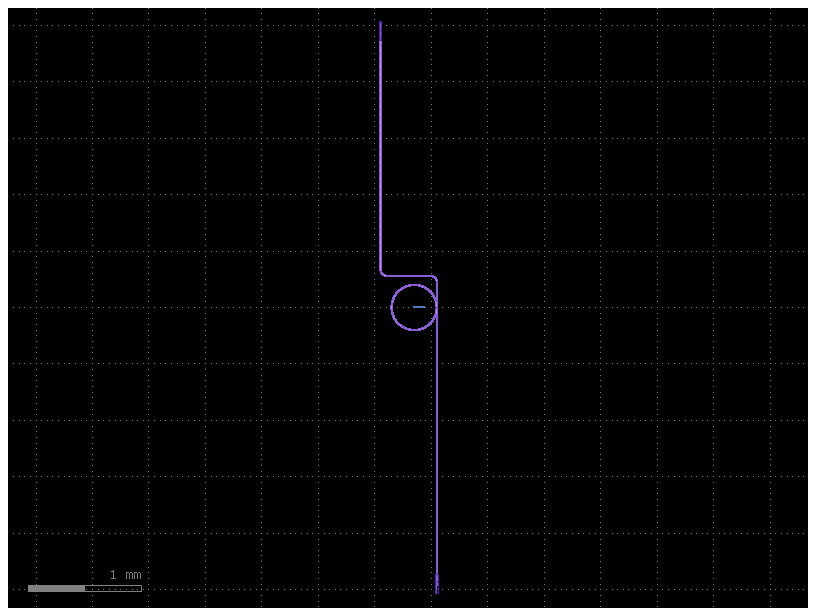

In [8]:
circuit_oband = ring_pass_circuit(communication_band="oband")
circuit_oband

### Assemble the C-band circuit

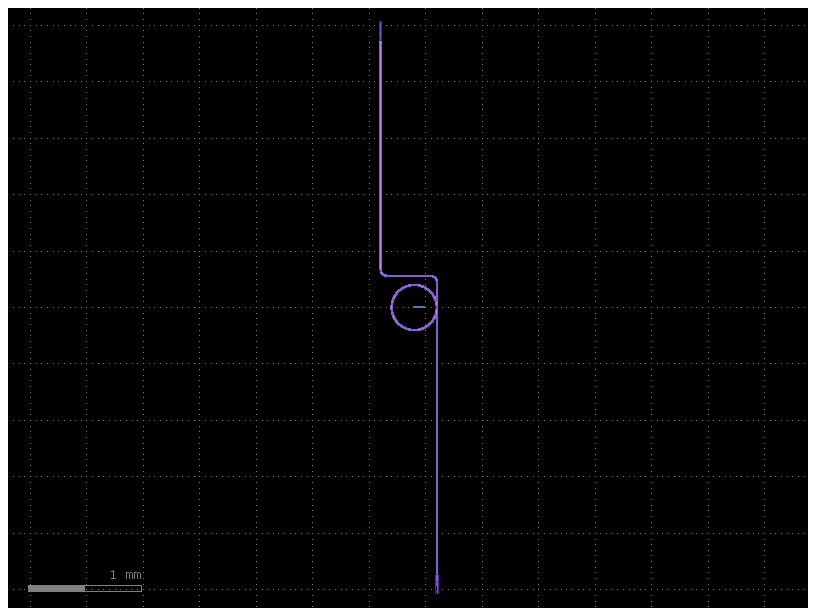

In [9]:
circuit_cband = ring_pass_circuit(communication_band="cband")
circuit_cband

### Get the O-band terminated EO modulator and edge couplers

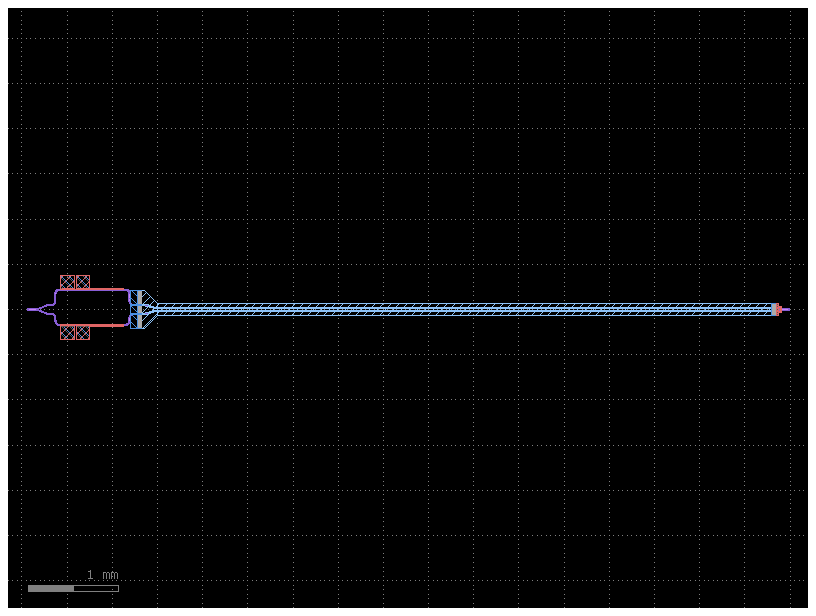

In [10]:
modulator_oband = gf.get_component(
    "terminated_mzm_1x2mmi_oband", modulation_length=6800.0, length_imbalance=120.0
)
modulator_oband

In [11]:
x_in = chip_layout.dxmin + 800.0
x_out = chip_layout.dxmax - 100.0
in_loc = np.array([x_in, chip_layout.dymax])
out_loc = np.array([x_out, chip_layout.dymin])

ec_in = gf.Component()
ec_oband = gf.get_component("edge_coupler_oband")
ec_ref = ec_in << ec_oband
ec_ref.drotate(-90.0)
ec_ref.dmove(
    ec_ref.ports["o1"].dcenter, in_loc + [0.0, 0.5 * ec_oband.settings["input_ext"]]
)
ec_in.add_ports(ec_ref.ports)

ec_out = gf.Component()
ec_ref = ec_out << ec_oband
ec_ref.drotate(90.0)
ec_ref.dmove(
    ec_ref.ports["o1"].dcenter, out_loc - [0.0, 0.5 * ec_oband.settings["input_ext"]]
)
ec_out.add_ports(ec_ref.ports)

ecs_oband_modulator = {
    "in": ec_in,
    "out": ec_out,
}

### Wirebonding pads

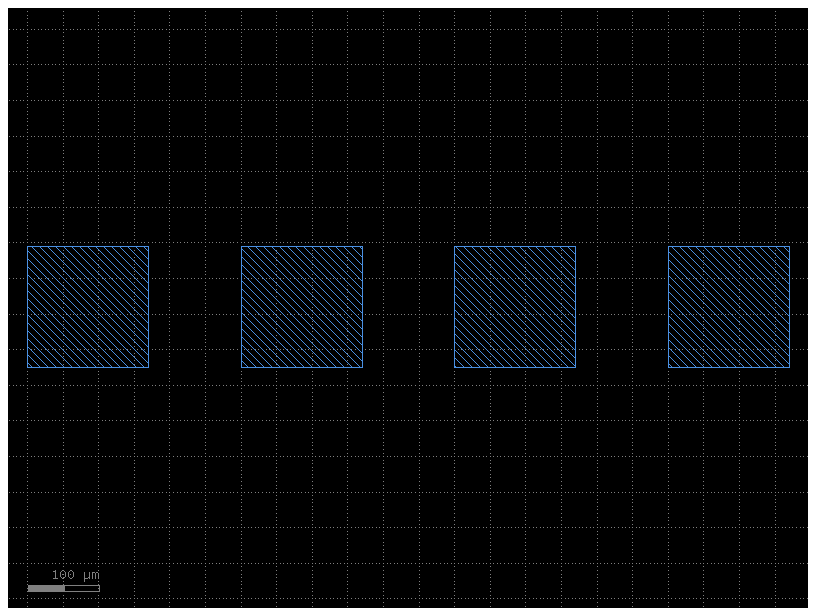

In [12]:
@gf.cell
def bondpad_array(
    pad_size: tuple = (170, 170),
    pitch: float = 300,
    N: int = 4,
    chip_frame: gf.Component = chip_layout,
    dx: float = 1400.0,
    dy: float = 4800.0,
):
    c = gf.Component()

    pad = gf.components.pad(
        size=pad_size,
        layer=LAYER.M2,
    )
    bp = c << gf.components.pad_array(
        pad=pad,
        columns=N,
        column_pitch=pitch,
        layer=LAYER.M2,
        auto_rename_ports=True,
        centered_ports=True,
        port_orientation=-90.0,
    )

    bp.dmove(
        origin=(bp.dxmin, bp.dymin),
        destination=(chip_frame.dxmin + dx, chip_frame.dymin + dy),
    )


    c.add_ports(bp.ports)

    return c


bp_array = bondpad_array()
bp_array

### Get the C-band terminated EO modulator and edge couplers

c:\Users\AndreiKiselev\anaconda3\envs\ltoi3000\Lib\site-packages\kfactory\decorators.py:406: UserWarning: via_array: 'signal' conductor cannot fit via rows (num_rows=0); using single solid opening.
  cell = f(**params)  # type: ignore[call-arg]


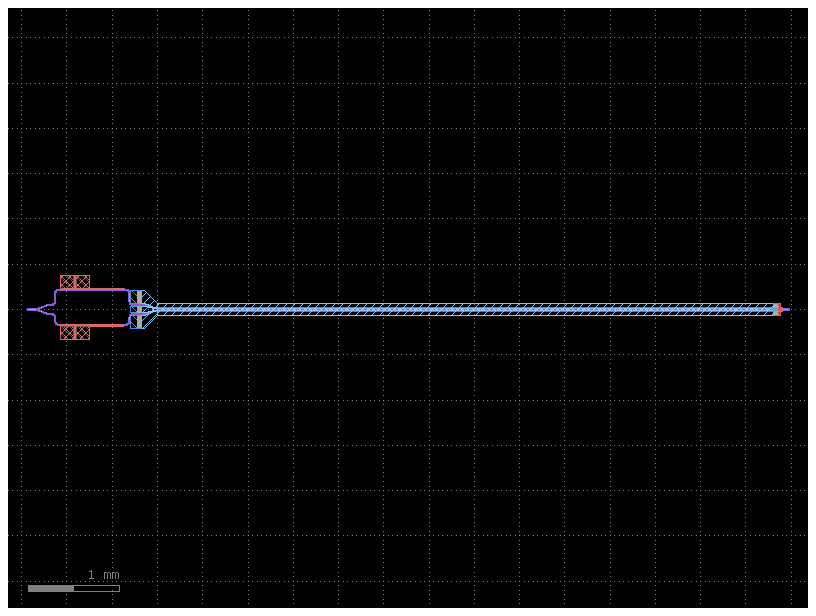

In [13]:
modulator_cband = gf.get_component(
    "terminated_mzm_1x2mmi_cband", modulation_length=6800.0, length_imbalance=120.0
)
modulator_cband

In [14]:
x_in = chip_layout.dxmin + 750.0
x_out = chip_layout.dxmax - 200.0
in_loc = np.array([x_in, chip_layout.dymax])
out_loc = np.array([x_out, chip_layout.dymin])

ec_in = gf.Component()
ec_cband = gf.get_component("edge_coupler_cband")
ec_ref = ec_in << ec_cband
ec_ref.drotate(-90.0)
ec_ref.dmove(
    ec_ref.ports["o1"].dcenter, in_loc + [0.0, 0.5 * ec_cband.settings["input_ext"]]
)
ec_in.add_ports(ec_ref.ports)

ec_out = gf.Component()
ec_ref = ec_out << ec_cband
ec_ref.drotate(90.0)
ec_ref.dmove(
    ec_ref.ports["o1"].dcenter, out_loc - [0.0, 0.5 * ec_cband.settings["input_ext"]]
)
ec_out.add_ports(ec_ref.ports)

ecs_cband_modulator = {
    "in": ec_in,
    "out": ec_out,
}

### Assembly of the modulator

In [15]:
routing_roc = 75.0


@gf.cell
def modulator_circuit(
    communication_band="oband",
    modulator_x_pos=-4000.0,
    modulator_y_pos=2000.0,
    bp_port_names: tuple = ("e3", "e4"),  # hashable port name strings
    waypoints_heater_routing: list = None,
) -> gf.Component:
    if communication_band == "oband":
        ecs = ecs_oband_modulator
        modulator = modulator_oband
    elif communication_band == "cband":
        ecs = ecs_cband_modulator
        modulator = modulator_cband
    else:
        raise ValueError("communication_band must be either 'oband' or 'cband'")

    c = gf.Component()
    mod_ref = c << modulator
    mod_ref.dmove(mod_ref.ports["o1"].dcenter, [modulator_x_pos, modulator_y_pos])
    # Bend spec

    routing_bend = partial(
        gf.components.bend_euler,
        radius=routing_roc,
        with_arc_floorplan=True,
    )

    # Routing to I/O

    [c << ec for ec in ecs.values()]

    route_bundle(
        c,
        ports1=[mod_ref.ports["o1"]],
        ports2=[ecs["in"].ports["o2"]],
        start_straight_length=5.0,
        end_straight_length=5.0,
        cross_section="xs_rwg700" if communication_band == "oband" else "xs_rwg900",
        bend=routing_bend,
        radius=routing_roc,
        straight="straight_rwg700_oband"
        if communication_band == "oband"
        else "straight_rwg900_cband",
    )

    route_bundle(
        c,
        ports1=[mod_ref.ports["o2"]],
        ports2=[ecs["out"].ports["o2"]],
        start_straight_length=5.0,
        end_straight_length=5.0,
        cross_section="xs_rwg700" if communication_band == "oband" else "xs_rwg900",
        bend=routing_bend,
        radius=routing_roc,
        straight="straight_rwg700_oband"
        if communication_band == "oband"
        else "straight_rwg900_cband",
    )

    # Routing to bondpad
    heater_routing_width = 40.0
    route_bundle(
        c,
        ports1=[mod_ref.ports["e3"], mod_ref.ports["e4"]],
        ports2=[bp_array.ports[bp_port_names[0]], bp_array.ports[bp_port_names[1]]],
        bend=gf.components.bend_circular,
        straight=gf.components.straight,
        auto_taper=False,
        allow_width_mismatch=True,
        layer=LAYER.M2,
        route_width=heater_routing_width,
        waypoints=waypoints_heater_routing,
        separation=10.0,
    )



    text_ref = c << gf.components.text(
        f"{communication_band}" + "_modulator", layer=LAYER.LABELS, size=13
    )
    text_ref.dmove(
        ((mod_ref.dxmin + mod_ref.dxmax) / 2, (mod_ref.dymin + mod_ref.dymax) / 2 + 100)
    )

    c.flatten()
    c.add_port(name="o1", port=ecs["in"].ports["o1"])
    c.add_port(name="o2", port=ecs["out"].ports["o1"])

    return c

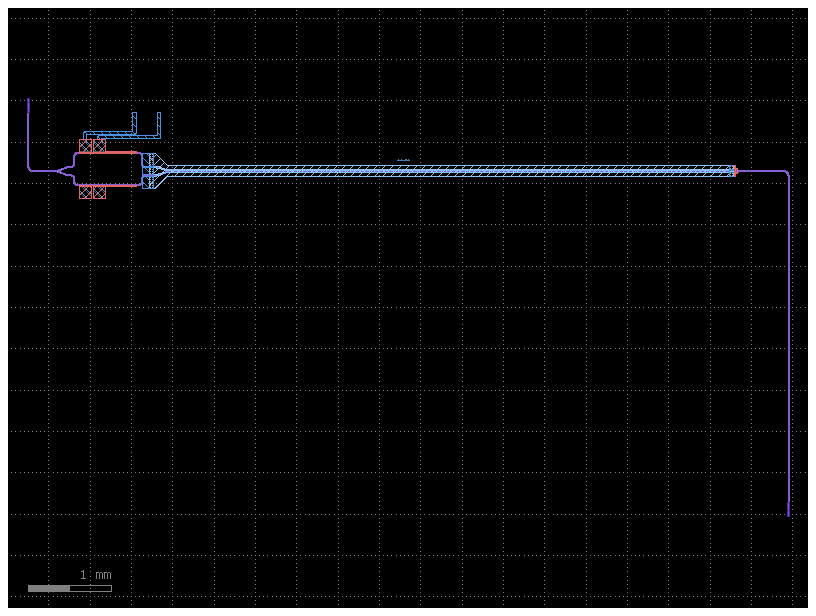

In [16]:
modulator_circuit_oband = modulator_circuit(
    "oband", modulator_x_pos=-4000.0, modulator_y_pos=1650.0, bp_port_names=("e2", "e1")
)
modulator_circuit_oband

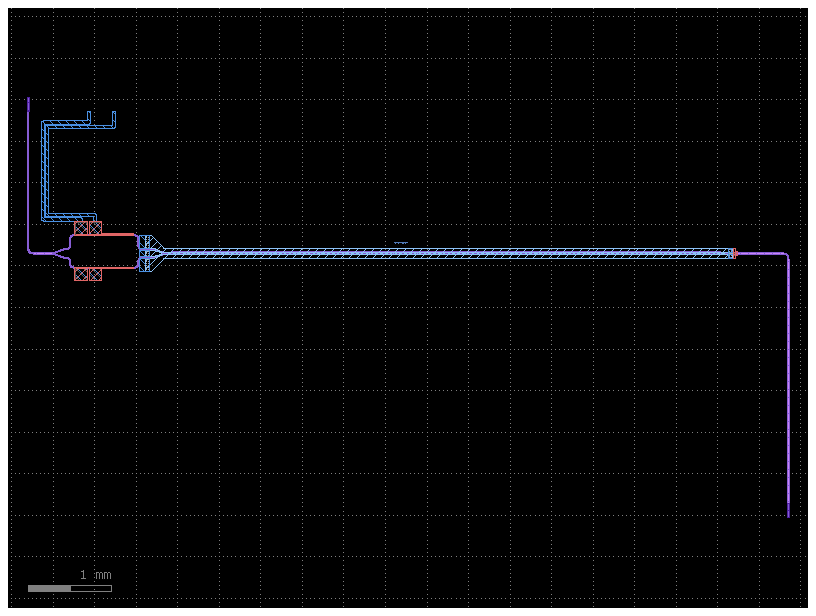

In [17]:
modulator_circuit_cband = modulator_circuit(
    "cband", modulator_x_pos=-4100.0, modulator_y_pos=650.0, bp_port_names=("e4", "e3"), waypoints_heater_routing=[(-4100, 1400), (-4100, 2200), (-3600, 2200)]
)
modulator_circuit_cband

Assemble on the die outline

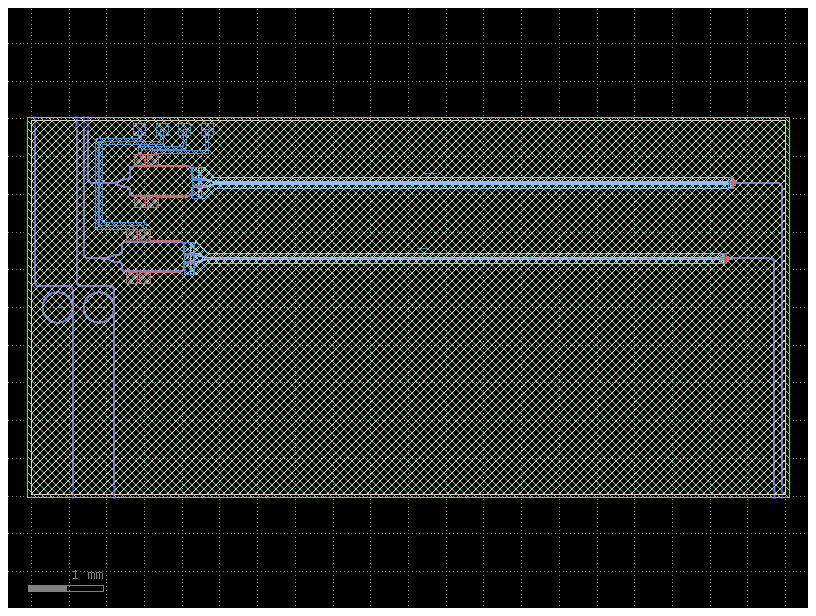

In [18]:
@gf.cell
def die_assembled(
    chip_layout=chip_layout,
) -> gf.Component:
    c = gf.Component()
    c << chip_layout
    c << circuit_oband
    c << circuit_cband
    c << modulator_circuit_oband
    c << modulator_circuit_cband
    c << bp_array

    c.add_ports(circuit_oband.ports, prefix="oband")
    c.add_ports(circuit_cband.ports, prefix="cband")

    return c


die = die_assembled()
die.plot()
die.show()
_ = die.write_gds(gdsdir=Path.cwd())

Recap the port positions for testing

In [19]:
die.pprint_ports()

┏━━━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ name    ┃ width ┃ orientation ┃ layer          ┃ center             ┃ port_type ┃
┡━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ obando1 │ 0.35  │ 90.0        │ LT_SLAB (3/10) │ (-4950.0, 2530.0)  │ optical   │
│ obando2 │ 0.35  │ 270.0       │ LT_SLAB (3/10) │ (-4450.0, -2530.0) │ optical   │
│ cbando1 │ 0.5   │ 90.0        │ LT_SLAB (3/10) │ (-4400.0, 2530.0)  │ optical   │
│ cbando2 │ 0.5   │ 270.0       │ LT_SLAB (3/10) │ (-3900.0, -2530.0) │ optical   │
└─────────┴───────┴─────────────┴────────────────┴────────────────────┴───────────┘

### Clear the gdsfactory cache

In [20]:
gf.clear_cache()